In [1]:
from scipy.spatial.transform import Rotation
import numpy as np
import scipy
import pathlib
import h5py
import pandas as pd
import seaborn as sns

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import median_absolute_deviation as mad_
from astropy.coordinates import CartesianRepresentation, SphericalRepresentation
import gala.integrate as gi
import gala.dynamics as gd
import gala.potential as gp
import gala.coordinates as gc
from gala.units import galactic
import yaml
from mwlmc import model as mwlmc_model
Model = mwlmc_model.MWLMC()

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
plt.style.use('my_standard.mplstyle')

galcen_v_sun = (11.1, 245, 7.3)*u.km/u.s
galcen_distance = 8.249*u.kpc

Initialising MW ... 
sphcoefs::read_coef_file: reading coefficients from file . . . success!!
Initialising LMC ... 
sphcoefs::read_coef_file: reading coefficients from file . . . success!!
Initialising MW disc ... 
cylcoefs::read_simple_coef_file: reading coefficients from file . . . success!!


sphcache::read_sph_cache: trying to read cached table . . . success!!
sphcache::read_sph_cache: trying to read cached table . . . success!!
cylcache::read_cyl_cache: trying to read cached table . . . success!!


In [12]:
# potentials = list(['rigid-mw.hdf5','static-mw.hdf5', 'rm-MWhalo-full-MWdisc-full-LMC.hdf5', 'em-MWhalo-full-MWdisc-full-LMC.hdf5',\
#                            'md-MWhalo-full-MWdisc-full-LMC.hdf5', 'mq-MWhalo-full-MWdisc-full-LMC.hdf5', 'mdq-MWhalo-full-MWdisc-full-LMC.hdf5',\
#                             'full-MWhalo-full-MWdisc-no-LMC.hdf5', 'full-MWhalo-full-MWdisc-full-LMC.hdf5'])

# labels = list(['Rigid MW without motion (no LMC)', 'Rigid MW + motion (no LMC)', 'Rigid Monopole \& LMC', 'Evolving Monopole \& LMC', \
#                'Monopole + Dipole \& LMC', 'Monopole + Quadrupole \& LMC',\
#                'Monopole + Dipole + Quadrupole \& LMC', 'Full Expansion (no LMC)', 'Full Expansion \& LMC'])

potentials = list(['rigid-mw.hdf5','rm-MWhalo-full-MWdisc-full-LMC.hdf5', 
                           'md-MWhalo-full-MWdisc-full-LMC.hdf5', 
                            'full-MWhalo-full-MWdisc-no-LMC.hdf5', 'full-MWhalo-full-MWdisc-full-LMC.hdf5'])

labels = list(['Rigid MW without motion (no LMC)', 'Rigid Monopole \& LMC', 
               'Monopole + Dipole \& LMC',
               'Full Expansion (no LMC)', 'Full Expansion \& LMC'])

data_path =  '/mnt/ceph/users/rbrooks/oceanus/analysis/stream-runs/combined-files/plotting_data/16384-dt1Myr/'

# Initialize a list to store DataFrames
df_list = []

# Loop through each file and label
for potential, label in zip(potentials, labels):
    with h5py.File(data_path + potential, 'r') as file:
        # Extract data from HDF5 file
        pericenters = np.array(file['pericenter'])
        apocenters = np.array(file['apocenter'])
        lengths = np.array(file['lengths'])
        widths = np.array(file['widths'])
        loc_veldis = np.array(file['loc_veldis'])
        track_deform = np.array(file['track_deform'])
        pm_ang = np.array(file['pm_misalignment'])
        l_pole_std = np.array(file['sigma_pole_l'])
        b_pole_std = np.array(file['sigma_pole_b'])
        
        # Create a DataFrame for the current potential
        df = pd.DataFrame({
            'pericenters': pericenters,
            'apocenters': apocenters,
            'lengths': lengths,
            'widths': widths,
            'loc_veldis': loc_veldis,
            'track_deform': track_deform,
            'pm_ang': pm_ang,
            'l_pole_std': l_pole_std,
            'b_pole_std': b_pole_std
        })
        
        # Add a column for the potential label
        df['potential_label'] = label
        
        # Append the DataFrame to the list
        df_list.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [14]:
combined_df[::16384]

,pericenters,apocenters,lengths,widths,loc_veldis,track_deform,pm_ang,l_pole_std,b_pole_std,potential_label
0,17.873679,33.880645,23.415374,0.171290,1.693258,0.027201,3.632831,1.303157,0.463302,Rigid MW without motion (no LMC)
16384,17.873679,33.880645,20.264997,0.169650,1.251125,0.039079,6.658911,1.149497,1.451649,Rigid Monopole \& LMC
32768,17.873679,33.880645,33.257159,0.182027,1.585473,0.138112,4.840119,1.336319,1.305658,Monopole + Dipole \& LMC
49152,17.873679,33.880645,24.064231,0.165639,1.440971,0.326248,5.719638,1.988445,1.903303,Full Expansion (no LMC)
65536,17.873679,33.880645,31.932187,0.184438,1.705193,0.130292,4.900045,1.291944,1.263246,Full Expansion \& LMC


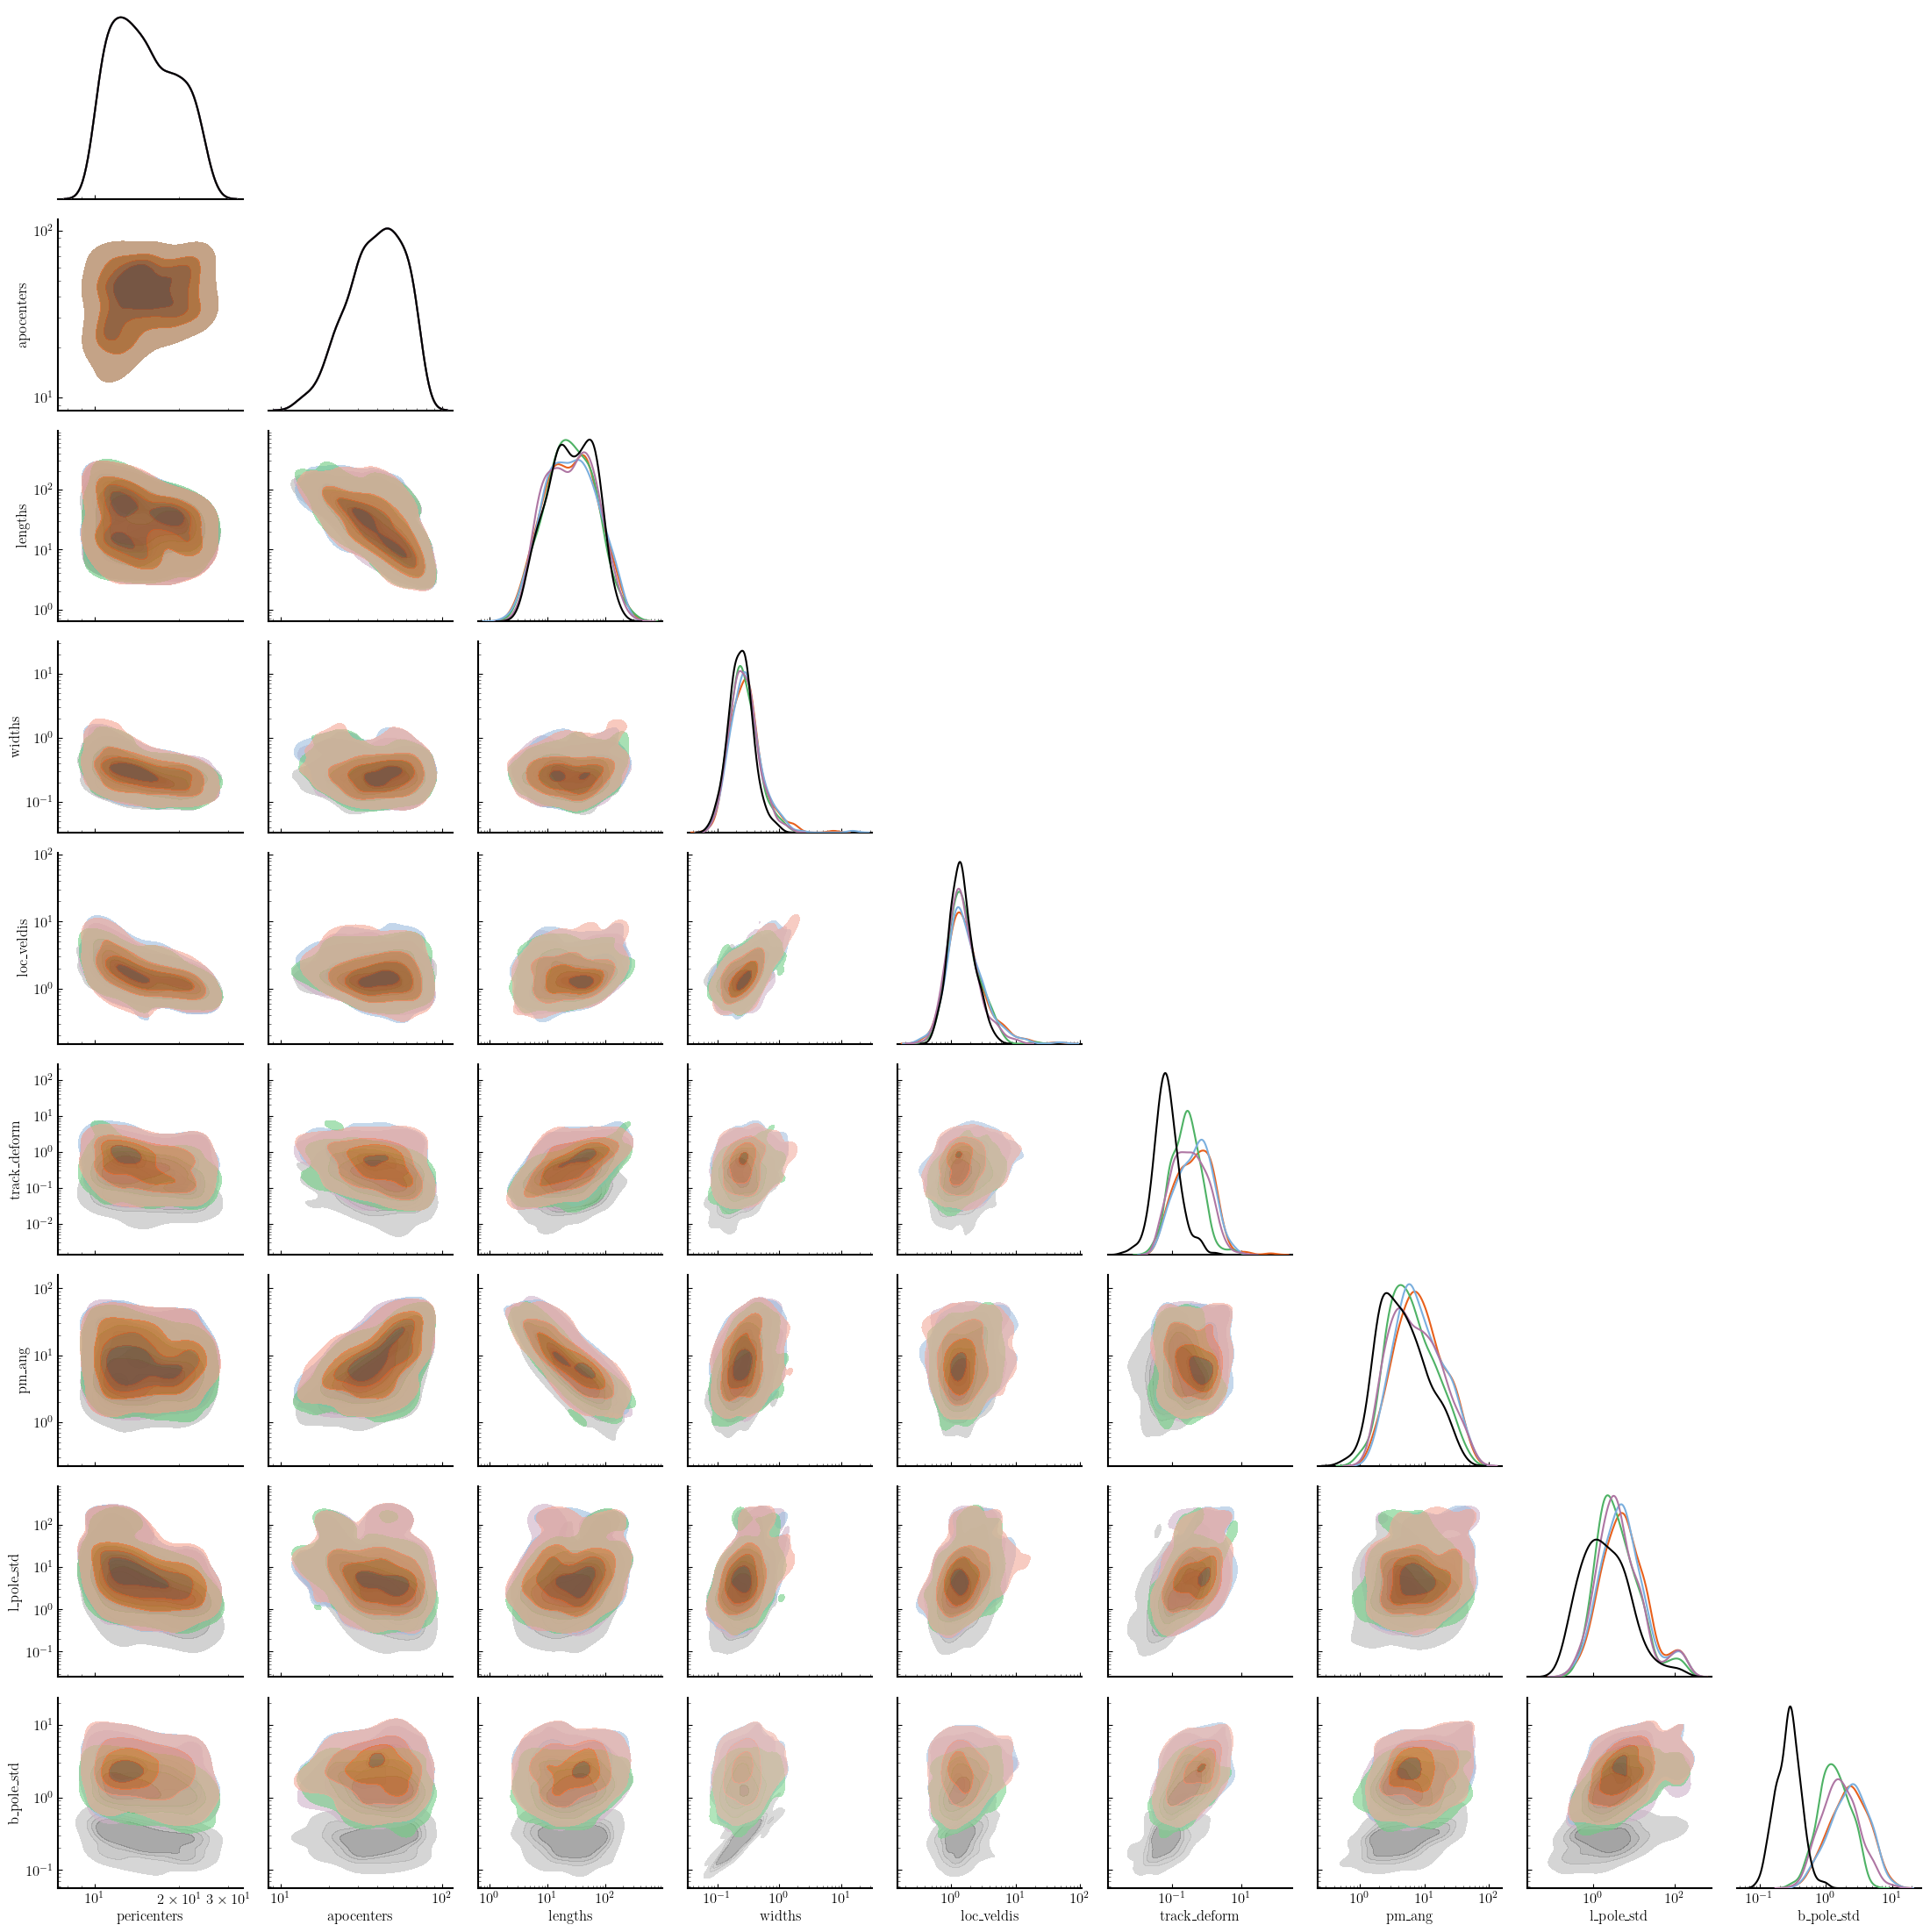

In [15]:
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# colors = ['k', '#AE76A3', '#7BAFDE', '#F7F056', '#E8601C', '#72190E']
colors = ['k', '#AE76A3', '#7BAFDE', '#4EB265', '#E8601C']

g = sns.PairGrid(combined_df[::64], vars=list(combined_df.keys())[:-1],
                 hue="potential_label", corner=True, palette = colors, diag_sharey=False)

g.map_diag(sns.kdeplot, legend=True, bw_adjust=1, log_scale=True)
g.map_lower(sns.kdeplot, legend=False, log_scale=True, fill=True, alpha=.6, levels=5)

plt.savefig('../analysis/figures/misc/2d-potl-pdfs')